# Prediction Model (Ranking-Based Popularity)

Predicting collaboration success (`log_streams`) using:
- **Ranking-based popularity** (`log_ranking_score_source/target`) instead of streams
- Hyperbolic distance
- Collaboration frequency (weight)
- Market and year

## 1. Imports & Data Loading

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
DATASET = 'model_dataset2.csv'
TARGET = 'log_streams'

# Load data
df = pd.read_csv(DATASET)
df = df.dropna(subset=['log_ranking_score_source', 'log_ranking_score_target'])

# Encode market
le_market = LabelEncoder()
df['market_enc'] = le_market.fit_transform(df['market'])

# Check if enao_similarity exists
if 'enao_similarity' not in df.columns:
    print("ERROR: 'enao_similarity' column not found!")
    print("Available columns:", df.columns.tolist())
    print("\n→ You need to re-run build_dataset.ipynb with the updated code first!")
else:
    print("✓ Dataset loaded successfully with enao_similarity column")

# Define all feature sets (used in different parts of analysis)
FEATURES = [
    'distance',
    'enao_similarity',
    'log_ranking_score_source',  
    'log_ranking_score_target', 
    'log_weight',
    'market_enc',
    'year'
]

FEATURES_NO_DIST = [
    'log_ranking_score_source',
    'log_ranking_score_target',
    'log_weight',
    'market_enc',
    'year'
]

FEATURES_WITH_DIST = [
    'distance',
    'log_ranking_score_source',  
    'log_ranking_score_target', 
    'log_weight',
    'market_enc',
    'year'
]

FEATURES_RANKING = [
    'distance', 
    'log_ranking_score_source', 
    'log_ranking_score_target', 
    'log_weight', 
    'market_enc', 
    'year'
]

FEATURES_STREAMS = [
    'distance', 
    'log_popularity_source', 
    'log_popularity_target', 
    'log_weight', 
    'market_enc', 
    'year'
]

# Prepare full dataset with all features
X = df[FEATURES]
y = df[TARGET]

# Train/test split (stratified by market)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['market']
)

# Create feature subsets for different analyses
X_train_no_dist = X_train[FEATURES_NO_DIST]
X_test_no_dist = X_test[FEATURES_NO_DIST]

print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")
print(f"\nAll features available: {FEATURES}")
print(f"Target: {TARGET}")

✓ Dataset loaded successfully with enao_similarity column

Train set: 34,928 samples
Test set:  8,733 samples

All features available: ['distance', 'enao_similarity', 'log_ranking_score_source', 'log_ranking_score_target', 'log_weight', 'market_enc', 'year']
Target: log_streams


## 2. Model Comparison with Hyperparameter Tuning

We compare three models, each with hyperparameter tuning:
- **Linear Regression** (Ridge) - tune alpha
- **Random Forest** - tune n_estimators, max_depth, min_samples_split, min_samples_leaf
- **Gradient Boosting** - tune n_estimators, max_depth, learning_rate, subsample

**Process:**
1. Randomized search with 3-fold CV to find best hyperparameters (20 iterations)
2. Evaluate best model with 5-fold CV on training set
3. Test on held-out test set

**Metrics:** 5-fold CV R² and Test R²

In [3]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Linear Regression
ridge_params = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
}

# 2. Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Gradient Boosting
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

models_params = {
    'Linear Regression': (Ridge(random_state=42), ridge_params),
    'Random Forest': (RandomForestRegressor(random_state=42, n_jobs=-1), rf_params),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), gb_params)
}

results = {}

print("="*70)
print("HYPERPARAMETER TUNING AND MODEL EVALUATION")
print("="*70)

for name, (model, params) in models_params.items():
    print(f"\n{name}:")
    print(f"  Tuning hyperparameters with 3-fold CV...")
    
    # Randomized search with 3-fold CV for tuning
    search = RandomizedSearchCV(
        model, params, n_iter=20, cv=3, scoring='r2',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)
    
    print(f"  Best params: {search.best_params_}")
    
    # Using best model for 5-fold CV evaluation
    best_model = search.best_estimator_
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, 
                                scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    print(f"  5-fold CV R²: {cv_mean:.4f} (±{cv_std:.4f})")
    
    # Testing set performance
    y_pred_test = best_model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"  Test R²:      {test_r2:.4f}")
    
    results[name] = {
        'model': best_model,
        'best_params': search.best_params_,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'test_r2': test_r2,
        'y_pred': y_pred_test
    }

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY (After Hyperparameter Tuning)")
print("="*70)
print(f"{'Model':<20} {'5-Fold CV R²':<20} {'Test R²':<15}")
print("-"*70)
for name, res in results.items():
    print(f"{name:<20} {res['cv_mean']:.4f} (±{res['cv_std']:.4f})    {res['test_r2']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['test_r2'])
best_model = results[best_model_name]['model']
best_test_r2 = results[best_model_name]['test_r2']
best_y_pred = results[best_model_name]['y_pred']
best_params = results[best_model_name]['best_params']

print("\n" + "="*70)
print(f"BEST MODEL: {best_model_name} (Test R² = {best_test_r2:.4f})")
print(f"Best parameters: {best_params}")
print("="*70)

HYPERPARAMETER TUNING AND MODEL EVALUATION

Linear Regression:
  Tuning hyperparameters with 3-fold CV...
  Best params: {'alpha': 0.1}
  5-fold CV R²: 0.1556 (±0.0063)
  Test R²:      0.1506

Random Forest:
  Tuning hyperparameters with 3-fold CV...


Exception ignored in: <function ResourceTracker.__del__ at 0x10266dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106ed9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10696dc60>
Traceback (most recent call last

  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


Exception ignored in: <function ResourceTracker.__del__ at 0x107119c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x109fa9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  5-fold CV R²: 0.6397 (±0.0048)
  Test R²:      0.6560

Gradient Boosting:
  Tuning hyperparameters with 3-fold CV...


Exception ignored in: <function ResourceTracker.__del__ at 0x10a6adc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
  5-fold CV R²: 0.6765 (±0.0018)
  Test R²:      0.6872

MODEL COMPARISON SUMMARY (After Hyperparameter Tuning)
Model                5-Fold CV R²         Test R²        
----------------------------------------------------------------------
Linear Regression    0.1556 (±0.0063)    0.1506
Random Forest        0.6397 (±0.0048)    0.6560
Gradient Boosting    0.6765 (±0.0018)    0.6872

BEST MODEL: Gradient Boosting (Test R² = 0.6872)
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}


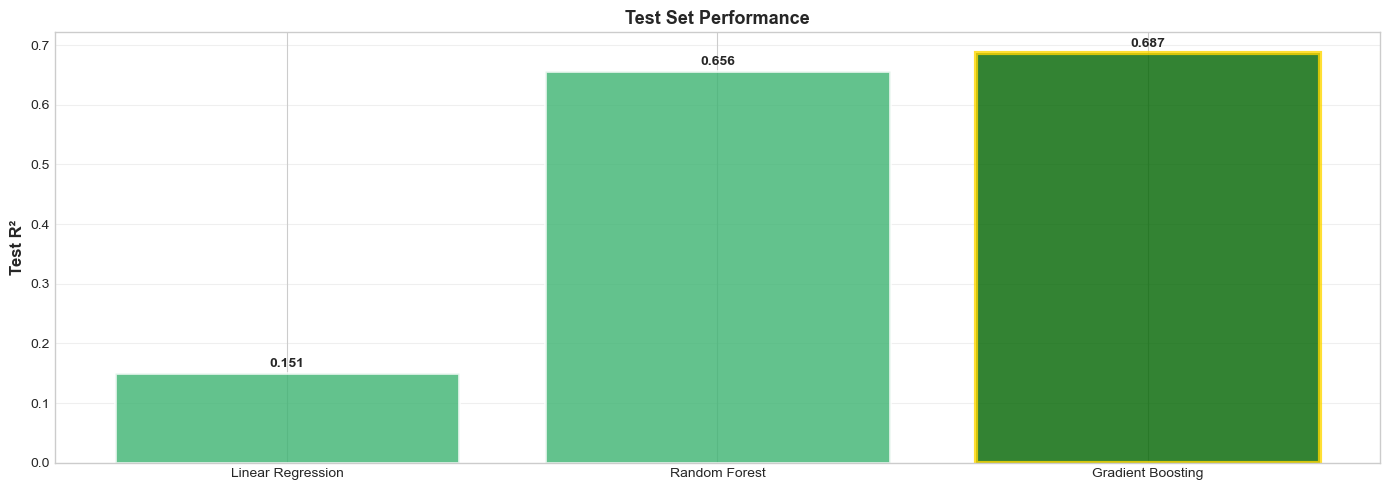

In [4]:
fig, (ax2) = plt.subplots(figsize=(14, 5))

model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]
test_r2s = [results[m]['test_r2'] for m in model_names]

bars = ax2.bar(model_names, test_r2s, 
               color='mediumseagreen', edgecolor='white', linewidth=2, alpha=0.8)
best_idx = model_names.index(best_model_name)
bars[best_idx].set_color('darkgreen')
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

ax2.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax2.set_title('Test Set Performance', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, r2 in enumerate(test_r2s):
    ax2.text(i, r2 + 0.01, f'{r2:.3f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Hyperbolic Distance vs ENAO Similarity

This section tests whether hyperbolic embeddings add value beyond raw ENAO co-occurrence weights.

**Three Models:**
- **Model B (Baseline):** No genre relationship feature
- **Model C (ENAO Similarity):** Direct ENAO co-occurrence matrix values
- **Model A (Hyperbolic Distance):** Hyperbolic distances from embeddings


In [5]:


features_base = [
    'log_ranking_score_source',
    'log_ranking_score_target',
    'log_weight',
    'market_enc',
    'year'
]

X_train_B = X_train[features_base]
X_test_B = X_test[features_base]

X_train_C = X_train[features_base + ['enao_similarity']]
X_test_C = X_test[features_base + ['enao_similarity']]

X_train_A = X_train[features_base + ['distance']]
X_test_A = X_test[features_base + ['distance']]

best_params = {
    'n_estimators': 300,
    'max_depth': 7,
    'learning_rate': 0.1,
    'random_state': 42
}



# Model B: Baseline
model_B = GradientBoostingRegressor(**best_params)
model_B.fit(X_train_B, y_train)
cv_scores_B = cross_val_score(model_B, X_train_B, y_train, cv=5, scoring='r2')
r2_test_B = model_B.score(X_test_B, y_test)

# Model C: ENAO Similarity
model_C = GradientBoostingRegressor(**best_params)
model_C.fit(X_train_C, y_train)
cv_scores_C = cross_val_score(model_C, X_train_C, y_train, cv=5, scoring='r2')
r2_test_C = model_C.score(X_test_C, y_test)

# Model A: Hyperbolic Distance
model_A = GradientBoostingRegressor(**best_params)
model_A.fit(X_train_A, y_train)
cv_scores_A = cross_val_score(model_A, X_train_A, y_train, cv=5, scoring='r2')
r2_test_A = model_A.score(X_test_A, y_test)



In [6]:
# ============================================================================
# Results
# ============================================================================

print(f'{"Model":<30} {"CV R²":<20} {"Test R²":<10} {"Improvement":<15}')
print('-' * 80)
print(f'{"B (Baseline)":<30} {cv_scores_B.mean():.3f} (±{cv_scores_B.std():.3f}){"":>6} {r2_test_B:.3f}{"":>6} {"—":<15}')
print(f'{"C (ENAO Similarity)":<30} {cv_scores_C.mean():.3f} (±{cv_scores_C.std():.3f}){"":>6} {r2_test_C:.3f}{"":>6} {f"+{r2_test_C - r2_test_B:.3f}":<15}')
print(f'{"A (Hyperbolic Distance)":<30} {cv_scores_A.mean():.3f} (±{cv_scores_A.std():.3f}){"":>6} {r2_test_A:.3f}{"":>6} {f"+{r2_test_A - r2_test_B:.3f}":<15}')
print()

# Statistical significance
pred_B = model_B.predict(X_test_B)
pred_C = model_C.predict(X_test_C)
pred_A = model_A.predict(X_test_A)

errors_B = (y_test.values - pred_B) ** 2
errors_C = (y_test.values - pred_C) ** 2
errors_A = (y_test.values - pred_A) ** 2

t_BC, p_BC = scipy_stats.ttest_rel(errors_B, errors_C)
t_BA, p_BA = scipy_stats.ttest_rel(errors_B, errors_A)
t_CA, p_CA = scipy_stats.ttest_rel(errors_C, errors_A)

print('Statistical Significance:')
print(f'  ENAO vs Baseline:      p = {p_BC:.6f} {"✓ significant" if p_BC < 0.05 else "✗ not significant"}')
print(f'  Hyperbolic vs Baseline: p = {p_BA:.6f} {"✓ significant" if p_BA < 0.05 else "✗ not significant"}')
print(f'  Hyperbolic vs ENAO:    p = {p_CA:.6f} {"✓ significant" if p_CA < 0.05 else "✗ not significant"}')
print()

# Feature importance
print('Feature Importance:')
print(f'  ENAO Similarity:     {model_C.feature_importances_[-1]:.3f}')
print(f'  Hyperbolic Distance: {model_A.feature_importances_[-1]:.3f}')

Model                          CV R²                Test R²    Improvement    
--------------------------------------------------------------------------------
B (Baseline)                   0.651 (±0.004)       0.655       —              
C (ENAO Similarity)            0.652 (±0.004)       0.651       +-0.003        
A (Hyperbolic Distance)        0.672 (±0.003)       0.680       +0.025         

Statistical Significance:
  ENAO vs Baseline:      p = 0.086407 ✗ not significant
  Hyperbolic vs Baseline: p = 0.000000 ✓ significant
  Hyperbolic vs ENAO:    p = 0.000000 ✓ significant

Feature Importance:
  ENAO Similarity:     0.012
  Hyperbolic Distance: 0.098


## 3. Best Model Analysis

Detailed analysis of the best-performing model.

Feature Importance:
                 feature  importance
              market_enc    0.599456
log_ranking_score_source    0.109262
                distance    0.099116
log_ranking_score_target    0.097286
              log_weight    0.058834
                    year    0.028463
         enao_similarity    0.007582


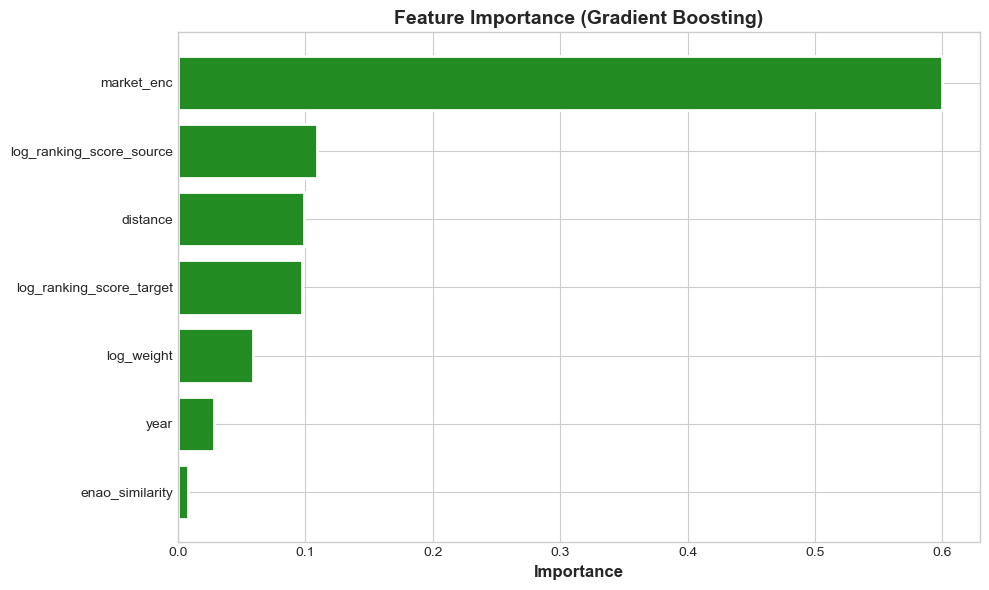

Exception ignored in: <function ResourceTracker.__del__ at 0x106941c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106c51c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11416dc60>
Traceback (most recent call last

In [7]:
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    feature_importance = pd.DataFrame({
        'feature': FEATURES,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Feature Importance:")
    print(feature_importance.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_importance['feature'], feature_importance['importance'],
            color='forestgreen', edgecolor='white', linewidth=2)
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Feature Importance ({best_model_name})',
                 fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):
    # Linear models
    coefficients = pd.DataFrame({
        'feature': FEATURES,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("Model Coefficients:")
    print(coefficients.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coefficients['coefficient']]
    ax.barh(coefficients['feature'], coefficients['coefficient'],
            color=colors, edgecolor='white', linewidth=2, alpha=0.7)
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'Model Coefficients ({best_model_name})',
                 fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()